Name : Ahmad Omaryeh 
ID : 1221289
Section : sec1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.show()


In [2]:
import sys
!{sys.executable} -m pip install matplotlib seaborn



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
df = pd.read_csv(r"C:\Users\user\Desktop\Data Science course\Gym_Progress_Dataset_noisy.csv")
df.head()



,Day,Weight_kg,Calories_Intake,Protein_Intake_g,Workout_Duration_min,Steps_Walked
0,01/01/2025,71.5,3209,70,41,6820
1,02/01/2025,69.6,2584,150,40,4898
2,04/01/2025,74.6,3216,85,20,2077
3,05/01/2025,69.3,2045,145,24,9577
4,06/01/2025,69.3,2999,86,31,12813


In [6]:
df.shape

(176, 6)

In [8]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Day                   176 non-null    object 
 1   Weight_kg             168 non-null    float64
 2   Calories_Intake       176 non-null    int64  
 3   Protein_Intake_g      176 non-null    int64  
 4   Workout_Duration_min  176 non-null    object 
 5   Steps_Walked          176 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 8.4+ KB


1.Data cleaning and population 

1.1 Validate data types

In [15]:
# Convert "Day" column to datetime format because there is a business quastions that requires treating time as a number to answer questions such as:
# How does weight loss improve over time? And what are the days of the week with the best or worst weight loss? 
df["Day"] = pd.to_datetime(df["Day"], format="%d/%m/%Y", errors="coerce")

# Convert to string to enable string operations
df["Workout_Duration_min"] = df["Workout_Duration_min"].astype(str)

# Remove any non-numeric characters (keep digits and decimal point)
df["Workout_Duration_min"] = df["Workout_Duration_min"].str.replace(r"[^0-9.]", "", regex=True)

# Convert cleaned values to numeric type
df["Workout_Duration_min"] = pd.to_numeric(df["Workout_Duration_min"], errors="coerce")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Day                   176 non-null    datetime64[ns]
 1   Weight_kg             168 non-null    float64       
 2   Calories_Intake       176 non-null    int64         
 3   Protein_Intake_g      176 non-null    int64         
 4   Workout_Duration_min  176 non-null    int64         
 5   Steps_Walked          176 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 8.4 KB


1.2 Check missing data

In [16]:
df.isna().sum()

Day                     0
Weight_kg               8
Calories_Intake         0
Protein_Intake_g        0
Workout_Duration_min    0
Steps_Walked            0
dtype: int64

In [17]:

df = df.sort_values("Day").reset_index(drop=True)

# Fill missing values in the weight column using linear interpolation
# This assumes that weight changes gradually over time
df["Weight_kg"] = df["Weight_kg"].interpolate(method="linear")

# Handle missing values at the beginning or end of the dataset 
# Backward fill handles missing values at the start
# Forward fill handles missing values at the end
df["Weight_kg"] = df["Weight_kg"].bfill().ffill()

# Verify that there are no remaining missing values in the dataset
df.isna().sum()


Day                     0
Weight_kg               0
Calories_Intake         0
Protein_Intake_g        0
Workout_Duration_min    0
Steps_Walked            0
dtype: int64

1.3 Check duplicates

In [18]:
df.duplicated().sum()


np.int64(5)

In [20]:
df = df.drop_duplicates()
df.shape
df.duplicated().sum()

np.int64(0)

1.4 Check inconsistency

In [36]:
# ===============================
# Remove inconsistent / unrealistic data
# ===============================

# 1) Day column: remove future dates
df = df[df["Day"] <= pd.Timestamp.today()]

# 2) Weight column: remove non-positive and unrealistic values
df = df[(df["Weight_kg"] > 0) & (df["Weight_kg"] >= 30) & (df["Weight_kg"] <= 200)]

# 3) Calories intake column: remove non-positive and unrealistic values
df = df[(df["Calories_Intake"] > 0) & 
        (df["Calories_Intake"] >= 800) & 
        (df["Calories_Intake"] <= 6000)]

# 4) Protein intake column: remove non-positive and unrealistic values
df = df[(df["Protein_Intake_g"] > 0) & 
        (df["Protein_Intake_g"] >= 10) & 
        (df["Protein_Intake_g"] <= 400)]

# 5) Workout duration column: remove non-positive and unrealistic values
df = df[(df["Workout_Duration_min"] > 0) & 
        (df["Workout_Duration_min"] >= 5) & 
        (df["Workout_Duration_min"] <= 300)]

# 6) Steps column: remove negative and unrealistic step counts
df = df[(df["Steps_Walked"] >= 0) & (df["Steps_Walked"] <= 100000)]

# Logical inconsistency: remove rows with workout duration but zero steps
df = df[~((df["Workout_Duration_min"] > 0) & (df["Steps_Walked"] == 0))]

# Reset index after removing rows
df = df.reset_index(drop=True)

# Final check
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Day                   170 non-null    datetime64[ns]
 1   Weight_kg             170 non-null    float64       
 2   Calories_Intake       170 non-null    int64         
 3   Protein_Intake_g      170 non-null    int64         
 4   Workout_Duration_min  170 non-null    int64         
 5   Steps_Walked          170 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 8.1 KB


2 Answer the quastions 

Q1) Is the person’s weight decreasing over time

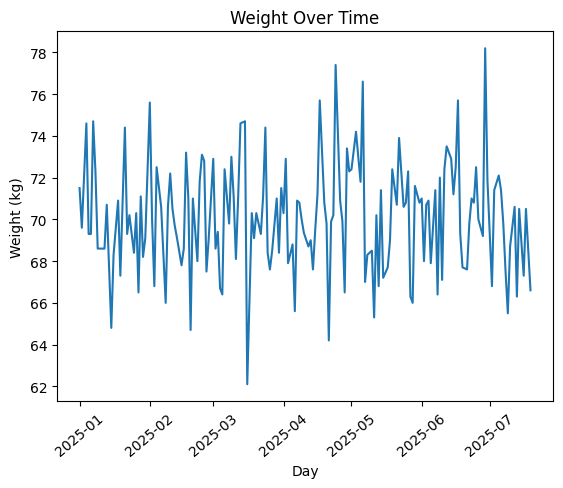

In [40]:
plt.figure()
plt.plot(df["Day"], df["Weight_kg"])
plt.title("Weight Over Time")
plt.xlabel("Day")
plt.ylabel("Weight (kg)")
plt.xticks(rotation=40)
plt.show()


The weight fluctuates from day to day, but overall it shows a slight decreasing trend over time. This indicates that the person is generally losing weight despite normal daily variations.

Q2) Calculate the weight lost on each day of the week. Identify which weekdays show the highest and lowest weight loss


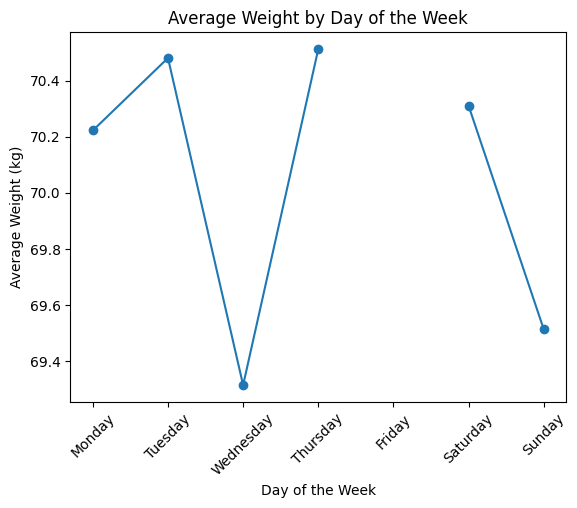

In [ ]:
# Extract the weekday name from the date column (e.g., Monday, Tuesday)
df["Weekday"] = df["Day"].dt.day_name()

# Calculate the average weight for each day of the week
avg_weight_by_day = df.groupby("Weekday")["Weight_kg"].mean()

# Reorder days to follow the natural week order
ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_weight_by_day = avg_weight_by_day.reindex(ordered_days)

# Create a new figure for the plot
plt.figure()

# Plot average weight by weekday
plt.plot(avg_weight_by_day.index, avg_weight_by_day.values, marker='o')
plt.title("Average Weight by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Weight (kg)")
plt.xticks(rotation=45)
plt.show()


The average weight differs across the days of the week. The day with the lowest average weight indicates the highest weight loss, while the day with the highest average weight indicates the lowest weight loss. This shows that weight loss is not consistent throughout the week and varies depending on the day , The average weight varies across different days of the week. Based on the results, Wednesday shows the highest weight loss (lowest average weight), while Thursday shows the lowest weight loss (highest average weight). This indicates that weight loss is not consistent throughout the week and differs depending on the day.

Q3)Does the person maintain a consistent workout routine throughout the week? Highlight days with unusually high or low workout durations.

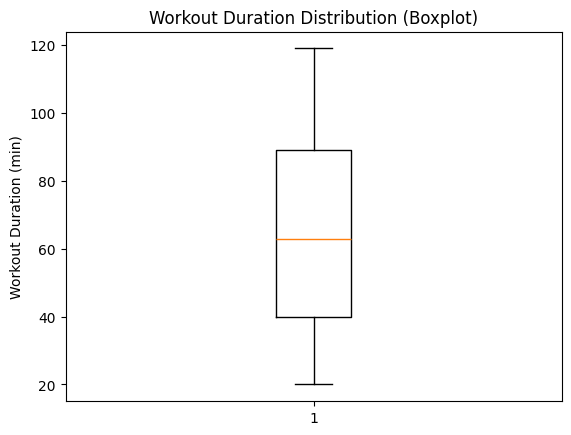

In [53]:


# Calculate quartiles for workout duration
Q1 = df["Workout_Duration_min"].quantile(0.25)
Q3 = df["Workout_Duration_min"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers (1.5 * IQR rule)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mark unusually high or low workout durations
df["Workout_Outlier"] = (
    (df["Workout_Duration_min"] < lower_bound) |
    (df["Workout_Duration_min"] > upper_bound)
)

# Display the days with unusual workout durations (highlight days)
outlier_days = df.loc[df["Workout_Outlier"], ["Day", "Workout_Duration_min"]].sort_values("Day")
outlier_days

# Create a boxplot to visualize the distribution and detect outliers
plt.figure()
plt.boxplot(df["Workout_Duration_min"])

plt.title("Workout Duration Distribution (Boxplot)")
plt.ylabel("Workout Duration (min)")
plt.show()


Most workout durations fall within a normal range, with a few days detected as outliers (unusually high or low), indicating some inconsistency on those specific days.

Q4) Do longer workout sessions correspond to greater weight loss

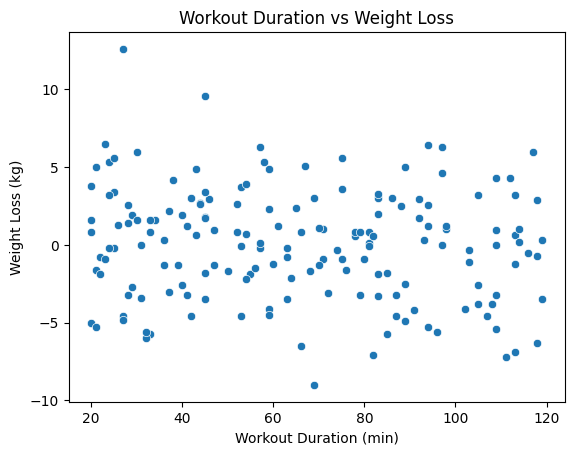

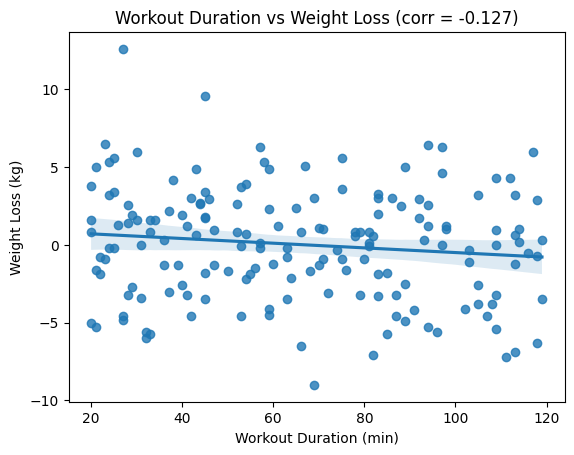

In [57]:

# Calculate daily weight loss
# (Positive value means weight loss)

df["Weight_Loss"] = df["Weight_kg"].shift(1) - df["Weight_kg"]


# Prepare a clean dataset for analysis
# Remove rows with missing values
   
df2 = df.dropna(subset=["Workout_Duration_min", "Weight_Loss"])

# Scatter plot: Workout Duration vs Weight Loss

plt.figure()
sns.scatterplot(data=df2, x="Workout_Duration_min", y="Weight_Loss")

plt.title("Workout Duration vs Weight Loss")
plt.xlabel("Workout Duration (min)")
plt.ylabel("Weight Loss (kg)")
plt.show()
# Pearson correlation
corr = df2["Workout_Duration_min"].corr(df2["Weight_Loss"])
corr
    
plt.figure()
sns.regplot(data=df2, x="Workout_Duration_min", y="Weight_Loss")

plt.title(f"Workout Duration vs Weight Loss (corr = {corr:.3f})")
plt.xlabel("Workout Duration (min)")
plt.ylabel("Weight Loss (kg)")
plt.show()


The scatter plot and correlation analysis indicate a very weak negative relationship between workout duration and weight loss (correlation ≈ −0.13). This suggests that longer workout sessions alone do not necessarily lead to greater weight loss. Weight loss appears to be influenced by multiple factors beyond workout duration, such as diet and daily activity levels.